# SASRec — 20-core Hotel Recommendation

## 1 — Config & Imports

In [1]:
import os, math, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

BASE_DIR = "/Users/jaswanthimandalapu/Documents/Sem2/CMPE 256 (Recommender Systems)/Final Project"
DATA_DIR = os.path.join(BASE_DIR, "llm_rec_data_20interactions")
CKPT     = os.path.join(BASE_DIR, "sasrec_20core_best.pt")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Model ────────────────────────────────────────────────────
MAX_LEN  = 50     # avg seq length is 28, 50 covers >95% of users
HIDDEN   = 128    # larger than 5-core SASRec: only 27K items, richer per-item signal
N_HEADS  = 4
N_LAYERS = 2
DROPOUT  = 0.2

# ── Training ─────────────────────────────────────────────────
BATCH_SIZE   = 512
EPOCHS       = 200
LR           = 1e-3
WEIGHT_DECAY = 1e-2
PATIENCE     = 20

# ── Evaluation ───────────────────────────────────────────────
N_NEG      = 100   # same as LightGBM for direct comparison
EVAL_BATCH = 512
KS         = [1, 5, 10, 20, 100]

PAD    = 0
OFFSET = 1   # item_idx i → vocab id i+1

Device: cpu


## 2 — Data Loading

In [2]:
COLS = ["user_idx", "item_idx", "timestamp"]

train_df = pd.read_parquet(os.path.join(DATA_DIR, "core", "interactions_train.parquet"), columns=COLS)
valid_df = pd.read_parquet(os.path.join(DATA_DIR, "core", "interactions_valid.parquet"), columns=COLS)
test_df  = pd.read_parquet(os.path.join(DATA_DIR, "core", "interactions_test.parquet"),  columns=COLS)
item_map = pd.read_parquet(os.path.join(DATA_DIR, "core", "item_id_mapping.parquet"))

n_items    = len(item_map)        # 27,197
n_users    = train_df["user_idx"].nunique()
vocab_size = n_items + OFFSET     # 0=PAD, 1..n_items

print(f"Users      : {n_users:,}")
print(f"Items      : {n_items:,}")
print(f"Train rows : {len(train_df):,}")
print(f"Valid rows : {len(valid_df):,}")
print(f"Test rows  : {len(test_df):,}")

Users      : 46,660
Items      : 27,197
Train rows : 1,306,782
Valid rows : 46,660
Test rows  : 46,660


## 3 — Build User Sequences

In [3]:
train_seqs = (
    train_df.sort_values("timestamp")
    .groupby("user_idx")["item_idx"]
    .apply(lambda x: x.to_numpy(dtype=np.int32))
    .to_dict()
)

valid_targets = valid_df.set_index("user_idx")["item_idx"].to_dict()
test_targets  = test_df.set_index("user_idx")["item_idx"].to_dict()

# Test input = train history + valid item
test_seqs = {
    u: np.append(train_seqs[u], valid_targets[u]).astype(np.int32)
    for u in test_targets
}

lengths = [len(s) for s in train_seqs.values()]
print(f"Seq lengths: min={min(lengths)}  max={max(lengths)}  "
      f"mean={np.mean(lengths):.1f}  median={np.median(lengths):.0f}")

Seq lengths: min=18  max=9871  mean=28.0  median=23


## 4 — Dataset

In [4]:
class SASRecDataset(Dataset):
    """
    For each user:
      input  : train_seq[:-1]  left-padded to MAX_LEN
      pos    : train_seq[1:]   next item at every position
      neg    : 1 random item per position (BPR negative)
    """
    def __init__(self, user_seqs, max_len, n_items):
        self.seqs    = list(user_seqs.values())
        self.max_len = max_len
        self.n_items = n_items

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        seq = self.seqs[idx]
        inp = seq[:-1][-self.max_len:]
        tgt = seq[1:][-self.max_len:]

        inp_ids = (inp + OFFSET).tolist()
        tgt_ids = (tgt + OFFSET).tolist()
        neg_ids = [random.randint(1, self.n_items) for _ in tgt_ids]

        pad = self.max_len - len(inp_ids)
        inp_ids = [PAD] * pad + inp_ids
        tgt_ids = [PAD] * pad + tgt_ids
        neg_ids = [PAD] * pad + neg_ids

        return (torch.tensor(inp_ids, dtype=torch.long),
                torch.tensor(tgt_ids, dtype=torch.long),
                torch.tensor(neg_ids, dtype=torch.long))

## 5 — SASRec Model

In [5]:
class SASRec(nn.Module):
    def __init__(self, vocab_size, hidden, n_heads, n_layers, max_len, dropout):
        super().__init__()
        self.item_emb = nn.Embedding(vocab_size, hidden, padding_idx=PAD)
        self.pos_emb  = nn.Embedding(max_len, hidden)
        self.emb_norm = nn.LayerNorm(hidden)
        self.emb_drop = nn.Dropout(dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=hidden, nhead=n_heads,
            dim_feedforward=hidden * 4,
            dropout=dropout, activation="gelu",
            batch_first=True, norm_first=True,
        )
        self.encoder  = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.out_norm = nn.LayerNorm(hidden)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def _causal_mask(self, L, device):
        m = torch.zeros(L, L, device=device)
        m.fill_(float("-inf"))
        return torch.triu(m, diagonal=1)

    def encode(self, x):
        B, L   = x.shape
        pos    = torch.arange(L, device=x.device).unsqueeze(0).expand(B, -1)
        pad_mask  = (x == PAD)
        attn_mask = self._causal_mask(L, x.device)
        h = self.emb_drop(self.emb_norm(self.item_emb(x) + self.pos_emb(pos)))
        h = self.encoder(h, mask=attn_mask, src_key_padding_mask=pad_mask)
        return self.out_norm(h)     # (B, L, hidden)

    def score(self, h, item_ids):
        """h: (B, hidden)  item_ids: (B, K)  →  (B, K) dot-product scores"""
        emb = self.item_emb(item_ids)           # (B, K, hidden)
        return (h.unsqueeze(1) * emb).sum(-1)   # (B, K)


model = SASRec(vocab_size, HIDDEN, N_HEADS, N_LAYERS, MAX_LEN, DROPOUT).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"SASRec  |  vocab={vocab_size:,}  hidden={HIDDEN}  layers={N_LAYERS}  heads={N_HEADS}")
print(f"Parameters: {n_params:,}")

SASRec  |  vocab=27,198  hidden=128  layers=2  heads=4
Parameters: 3,884,800


/var/folders/z9/qf_jqt0s51n7dd3yz7l8gh840000gn/T/ipykernel_24743/1237301506.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder  = nn.TransformerEncoder(enc_layer, num_layers=n_layers)


## 6 — Training

In [6]:
train_ds = SASRecDataset(train_seqs, MAX_LEN, n_items)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=0, pin_memory=(DEVICE.type == "cuda"))

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR * 0.01)

print(f"Users / epoch : {len(train_ds):,}")
print(f"Batches/epoch : {len(train_dl):,}")


def bpr_loss(pos_scores, neg_scores, mask):
    loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8)
    return (loss * mask).sum() / mask.sum()


def train_one_epoch(model, dl):
    model.train()
    total = 0.0
    for inp, pos, neg in dl:
        inp, pos, neg = inp.to(DEVICE), pos.to(DEVICE), neg.to(DEVICE)
        mask = (pos != PAD).float()

        h          = model.encode(inp)                              # (B, L, H)
        pos_scores = model.score(h.view(-1, HIDDEN),
                                 pos.view(-1, 1)).squeeze(-1).view(inp.shape)
        neg_scores = model.score(h.view(-1, HIDDEN),
                                 neg.view(-1, 1)).squeeze(-1).view(inp.shape)

        loss = bpr_loss(pos_scores, neg_scores, mask)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(dl)

Users / epoch : 46,660
Batches/epoch : 92


## 7 — Evaluation (100 Sampled Negatives)

In [7]:
def _build_eval_input(user_seqs, max_len):
    rows, order = [], []
    for u, seq in user_seqs.items():
        tokens = (seq[-max_len:] + OFFSET).tolist()
        pad    = max_len - len(tokens)
        rows.append([PAD] * pad + tokens)
        order.append(u)
    return torch.tensor(rows, dtype=torch.long), order


@torch.no_grad()
def evaluate(model, user_seqs, targets, ks=KS):
    model.eval()
    all_input, user_order = _build_eval_input(user_seqs, MAX_LEN)

    hits  = {k: 0   for k in ks}
    ndcgs = {k: 0.0 for k in ks}
    n_eval = 0
    rng = np.random.default_rng(SEED)

    for start in range(0, len(user_order), EVAL_BATCH):
        end         = start + EVAL_BATCH
        batch_in    = all_input[start:end].to(DEVICE)
        batch_users = user_order[start:end]
        B           = batch_in.shape[0]

        h_last = model.encode(batch_in)[:, -1, :]              # (B, hidden)

        # 1 positive + 100 random negatives per user
        neg_ids  = torch.tensor(
            rng.integers(1, n_items + 1, size=(B, N_NEG)), dtype=torch.long, device=DEVICE
        )
        pos_ids  = torch.tensor(
            [targets[u] + OFFSET for u in batch_users], dtype=torch.long, device=DEVICE
        ).unsqueeze(1)                                          # (B, 1)
        candidates = torch.cat([pos_ids, neg_ids], dim=1)      # (B, 101)

        scores = model.score(h_last, candidates)               # (B, 101)
        # Rank of positive (index 0): items scoring strictly higher
        ranks  = (scores[:, 1:] > scores[:, :1]).sum(dim=1) + 1

        for rank in ranks.tolist():
            for k in ks:
                if rank <= k:
                    hits[k]  += 1
                    ndcgs[k] += 1.0 / math.log2(rank + 1)
            n_eval += 1

    return {f"Hit@{k}": hits[k]/n_eval for k in ks} | \
           {f"NDCG@{k}": ndcgs[k]/n_eval for k in ks}, n_eval

## 8 — Training Loop

In [8]:
best_ndcg10   = 0.0
best_state    = None
patience_left = PATIENCE
history       = []
t0            = time.time()

for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch(model, train_dl)
    scheduler.step()

    val_metrics, n_val = evaluate(model, train_seqs, valid_targets)
    ndcg10 = val_metrics["NDCG@10"]

    history.append({"epoch": epoch, "loss": round(loss, 4),
                    **{k: round(v, 4) for k, v in val_metrics.items()}})

    improved = ndcg10 > best_ndcg10
    if improved:
        best_ndcg10   = ndcg10
        best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_left = PATIENCE
        torch.save(best_state, CKPT)
    else:
        patience_left -= 1

    elapsed = (time.time() - t0) / 60
    marker  = " ★" if improved else ""
    print(f"Epoch {epoch:3d}/{EPOCHS}  loss={loss:.4f}  "
          f"Hit@10={val_metrics['Hit@10']:.4f}  NDCG@10={ndcg10:.4f}  "
          f"[best={best_ndcg10:.4f}]  {elapsed:.1f}min{marker}")

    if patience_left == 0:
        print(f"Early stopping at epoch {epoch}.")
        break

print(f"\nBest val NDCG@10 = {best_ndcg10:.4f}")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


Epoch   1/200  loss=0.6145  Hit@10=0.9599  NDCG@10=0.9523  [best=0.9523]  0.8min ★
Epoch   2/200  loss=0.5552  Hit@10=0.9640  NDCG@10=0.9546  [best=0.9546]  1.5min ★
Epoch   3/200  loss=0.4088  Hit@10=0.9687  NDCG@10=0.9575  [best=0.9575]  2.3min ★
Epoch   4/200  loss=0.3354  Hit@10=0.9726  NDCG@10=0.9600  [best=0.9600]  3.0min ★
Epoch   5/200  loss=0.2888  Hit@10=0.9752  NDCG@10=0.9617  [best=0.9617]  3.8min ★
Epoch   6/200  loss=0.2561  Hit@10=0.9764  NDCG@10=0.9630  [best=0.9630]  4.5min ★
Epoch   7/200  loss=0.2325  Hit@10=0.9770  NDCG@10=0.9637  [best=0.9637]  5.3min ★
Epoch   8/200  loss=0.2141  Hit@10=0.9779  NDCG@10=0.9643  [best=0.9643]  6.0min ★
Epoch   9/200  loss=0.1998  Hit@10=0.9777  NDCG@10=0.9644  [best=0.9644]  6.8min ★
Epoch  10/200  loss=0.1871  Hit@10=0.9784  NDCG@10=0.9646  [best=0.9646]  7.5min ★
Epoch  11/200  loss=0.1771  Hit@10=0.9787  NDCG@10=0.9650  [best=0.9650]  8.3min ★
Epoch  12/200  loss=0.1685  Hit@10=0.9785  NDCG@10=0.9649  [best=0.9650]  9.1min
Epoch 

## 9 — Final Results

In [9]:
model.load_state_dict(best_state or torch.load(CKPT, map_location=DEVICE))

val_metrics,  n_val  = evaluate(model, train_seqs, valid_targets)
test_metrics, n_test = evaluate(model, test_seqs,  test_targets)

results = pd.DataFrame({"Validation": val_metrics, "Test": test_metrics})
results.index.name = "Metric"

print("=" * 60)
print(f"  SASRec (20-core)  |  users={n_test:,}  negatives={N_NEG}")
print(f"  hidden={HIDDEN}  layers={N_LAYERS}  max_len={MAX_LEN}")
print("=" * 60)
display(results.style.format("{:.4f}").set_caption(
    f"Hit@K and NDCG@K — {N_NEG} sampled negatives"))

  SASRec (20-core)  |  users=46,660  negatives=100
  hidden=128  layers=2  max_len=50


,Validation,Test
Metric,,
Hit@1,0.9545,0.9512
Hit@5,0.9693,0.9679
Hit@10,0.9786,0.9776
Hit@20,0.9882,0.9877
Hit@100,1.0000,1.0000
NDCG@1,0.9545,0.9512
NDCG@5,0.9622,0.9598
NDCG@10,0.9652,0.9629
NDCG@20,0.9676,0.9654


## 10 — Training Curve

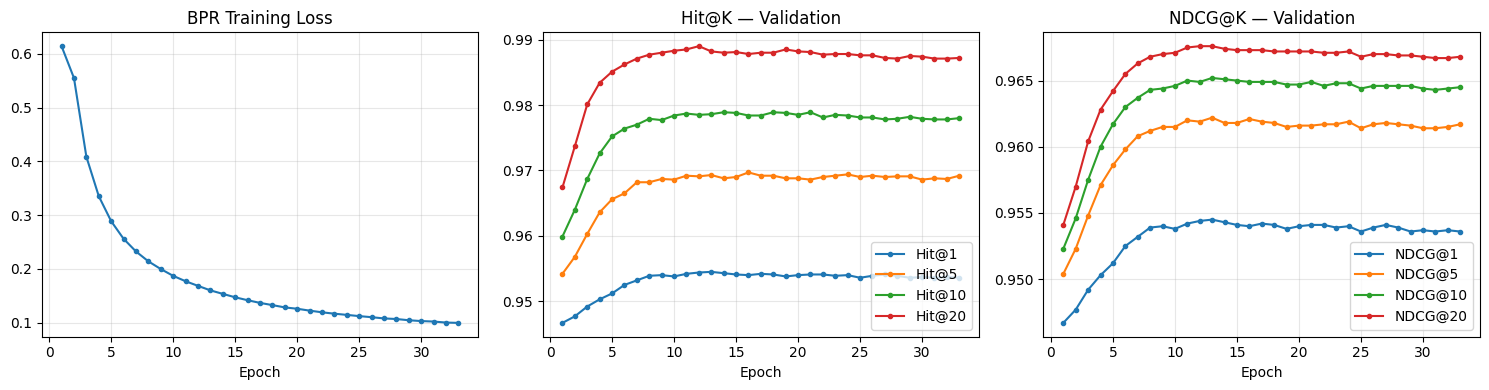

In [10]:
import matplotlib.pyplot as plt

hist = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(hist["epoch"], hist["loss"], marker="o", markersize=3)
axes[0].set_title("BPR Training Loss"); axes[0].set_xlabel("Epoch")
axes[0].grid(True, alpha=0.3)

for k in [1, 5, 10, 20]:
    axes[1].plot(hist["epoch"], hist[f"Hit@{k}"], marker="o", markersize=3, label=f"Hit@{k}")
axes[1].set_title("Hit@K — Validation"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

for k in [1, 5, 10, 20]:
    axes[2].plot(hist["epoch"], hist[f"NDCG@{k}"], marker="o", markersize=3, label=f"NDCG@{k}")
axes[2].set_title("NDCG@K — Validation"); axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "sasrec_20core_curve.png"), dpi=150, bbox_inches="tight")
plt.show()